# **1. Import Libraries and Load CSO PxStat Data**

This section imports the Python libraries required for data manipulation, visualisation and forecasting, and retrieves the TEM12 vehicle registration dataset directly from the CSO PxStat API.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# CSO PxStat API endpoint for TEM12:
# New Vehicles Licensed for the First Time

url = "https://ws.cso.ie/public/api.restful/PxStat.Data.Cube_API.ReadDataset/TEM12/CSV/1.0/en"

# Read the CSV data directly from the CSO PxStat API into a pandas DataFrame
df = pd.read_csv(url)

# Preview the first few rows
df.head()

,STATISTIC,Statistic Label,TLIST(M1),Month,C02172V02618,Type of Vehicle Registration,C01841V02268,Type of Fuel,UNIT,VALUE
0,TEM12,New Vehicles Licensed for the First Time,201501,2015 January,-,All Vehicles,-,All fuel types,Number,23152.0
1,TEM12,New Vehicles Licensed for the First Time,201501,2015 January,-,All Vehicles,1,Petrol,Number,5424.0
2,TEM12,New Vehicles Licensed for the First Time,201501,2015 January,-,All Vehicles,2,Diesel,Number,17334.0
3,TEM12,New Vehicles Licensed for the First Time,201501,2015 January,-,All Vehicles,3,Other fuel types,Number,0.0
4,TEM12,New Vehicles Licensed for the First Time,201501,2015 January,-,All Vehicles,4,Petrol and electric hybrid,Number,283.0


# **2. Explore and Understand the Dataset**

Before beginning the analysis, the dataset is explored to understand its structure, time period coverage, and the available fuel categories. This helps identify the relevant variables required for the project.

In [ ]:
# Convert Month column to datetime for accurate date checks
temp_dates = pd.to_datetime(df["Month"], format="%Y %B")

# Check available date range
print("Date Range:")
print(temp_dates.min())
print(temp_dates.max())

# Check dataset dimensions
print("\nDataset Shape:")
print(df.shape)

# Check available fuel types
print("\nFuel Types:")
print(df["Type of Fuel"].unique())

Date Range:
2015-01-01 00:00:00
2026-05-01 00:00:00

Dataset Shape:
(16440, 10)

Fuel Types:
['All fuel types' 'Petrol' 'Diesel' 'Other fuel types'
 'Petrol and electric hybrid' 'Electric'
 'Petrol or Diesel plug-in hybrid electric' 'Diesel and electric hybrid']


### Findings

The TEM12 dataset covers the period from January 2015 to March 2026 and contains 16,320 records across 10 variables. The dataset includes several fuel categories, including petrol, diesel, hybrid, plug-in hybrid electric and battery electric vehicles. The primary analysis focuses on Battery Electric Vehicles (BEVs), represented by the Electric fuel category. Plug-in Hybrid Electric Vehicles (PHEVs) are included in comparative analysis to provide additional insight into vehicle electrification trends in Ireland. The dataset is subsequently filtered to include the project analysis period of January 2016 to December 2025.

# **3. Filter Electric Vehicle Data**

The dataset contains registrations for multiple fuel types. The primary focus of this project is on Battery Electric Vehicles (BEVs), which are represented by the Electric fuel category. To provide additional context on the transition towards vehicle electrification in Ireland, Plug-in Hybrid Electric Vehicles (PHEVs) are also included in comparative analysis. The Month field is converted to a datetime format to allow filtering and time-based analysis.

In [ ]:
# Convert Month to datetime
df["Month"] = pd.to_datetime(
    df["Month"],
    format="%Y %B"
)

# Keep Battery Electric Vehicles only
df_ev = df[
    df["Type of Fuel"] == "Electric"
].copy()

# Define additional fuel category for later comparison
phev_fuels = [
    "Petrol or Diesel plug-in hybrid electric"
]

df_ev.head()

,STATISTIC,Statistic Label,TLIST(M1),Month,C02172V02618,Type of Vehicle Registration,C01841V02268,Type of Fuel,UNIT,VALUE
5,TEM12,New Vehicles Licensed for the First Time,201501,2015-01-01,-,All Vehicles,6,Electric,Number,68.0
13,TEM12,New Vehicles Licensed for the First Time,201501,2015-01-01,011,New Private Cars,6,Electric,Number,68.0
21,TEM12,New Vehicles Licensed for the First Time,201501,2015-01-01,012,New Goods Vehicles,6,Electric,Number,0.0
29,TEM12,New Vehicles Licensed for the First Time,201501,2015-01-01,013,New Tractors,6,Electric,Number,0.0
37,TEM12,New Vehicles Licensed for the First Time,201501,2015-01-01,01301,New Agriculture Tractors,6,Electric,Number,NaN


# **4. Filter the Analysis Period (2016–2025)**

The project focuses on electric vehicle registrations between 2016 and 2025. Records outside this period are removed to align the dataset with the defined project scope.

In [ ]:
# Filter project period

df_ev = df_ev[
    (df_ev["Month"] >= "2016-01-01") &
    (df_ev["Month"] <= "2025-12-31")
]

# Check remaining records and date range

print(df_ev.shape)
print(df_ev["Month"].min())
print(df_ev["Month"].max())

(1800, 10)
2016-01-01 00:00:00
2025-12-01 00:00:00


### Findings

The dataset was filtered to include records between January 2016 and December 2025. This reduced the dataset to 1,800 records and ensured that the analysis aligns with the timeframe defined in the project scope.

# **5. Filter New Private Car Registrations**

The dataset contains multiple vehicle registration categories, including goods vehicles, tractors and motorcycles. This project focuses on new private car registrations as they provide the most relevant measure of electric vehicle adoption by consumers.

In [ ]:
# Keep New Private Cars only

df_ev_private = df_ev[
    df_ev["Type of Vehicle Registration"] == "New Private Cars"
].copy()

# Check the results

print(df_ev_private.shape)

df_ev_private.head()

(120, 10)


,STATISTIC,Statistic Label,TLIST(M1),Month,C02172V02618,Type of Vehicle Registration,C01841V02268,Type of Fuel,UNIT,VALUE
1453,TEM12,New Vehicles Licensed for the First Time,201601,2016-01-01,011,New Private Cars,6,Electric,Number,32.0
1573,TEM12,New Vehicles Licensed for the First Time,201602,2016-02-01,011,New Private Cars,6,Electric,Number,92.0
1693,TEM12,New Vehicles Licensed for the First Time,201603,2016-03-01,011,New Private Cars,6,Electric,Number,81.0
1813,TEM12,New Vehicles Licensed for the First Time,201604,2016-04-01,011,New Private Cars,6,Electric,Number,51.0
1933,TEM12,New Vehicles Licensed for the First Time,201605,2016-05-01,011,New Private Cars,6,Electric,Number,23.0


### Findings

The dataset was further filtered to include only new private electric car registrations. This removes commercial and specialist vehicle categories that are outside the scope of the project and focuses the analysis on consumer EV adoption.

# **6. Calculate Annual Electric Vehicle Registrations**

Monthly registration data is aggregated into annual totals to identify trends in electric vehicle adoption over time.

In [ ]:
# Extract Year from Month

df_ev_private["Year"] = df_ev_private["Month"].dt.year

# Calculate annual EV registrations

ev_yearly = (
    df_ev_private
    .groupby("Year")["VALUE"]
    .sum()
    .reset_index()
)

# Display annual totals

ev_yearly

,Year,VALUE
0,2016,392.0
1,2017,623.0
2,2018,1222.0
3,2019,3443.0
4,2020,3940.0
5,2021,8554.0
6,2022,15462.0
7,2023,22493.0
8,2024,17191.0
9,2025,23398.0


### Findings

The monthly registration data was grouped by year to calculate annual electric vehicle registrations. This provides a clearer view of long-term adoption trends and allows changes in EV uptake to be assessed over time.

# **7. Calculate Cumulative EV Registrations**

Cumulative registrations are calculated to show the total number of new private electric vehicles registered over time and to assess progress towards Ireland’s 2030 EV targets.

In [ ]:
# Calculate cumulative registrations

ev_yearly["Cumulative_EV"] = ev_yearly["VALUE"].cumsum()

# Display results

ev_yearly

,Year,VALUE,Cumulative_EV
0,2016,392.0,392.0
1,2017,623.0,1015.0
2,2018,1222.0,2237.0
3,2019,3443.0,5680.0
4,2020,3940.0,9620.0
5,2021,8554.0,18174.0
6,2022,15462.0,33636.0
7,2023,22493.0,56129.0
8,2024,17191.0,73320.0
9,2025,23398.0,96718.0


### Findings

Cumulative registrations provide an indication of the overall growth in electric vehicle adoption and allow progress towards Ireland's long-term electrification targets to be assessed.

# **8. Visualise Annual EV Registration Trends**

A line chart is used to visualise annual electric vehicle registrations between 2016 and 2025.

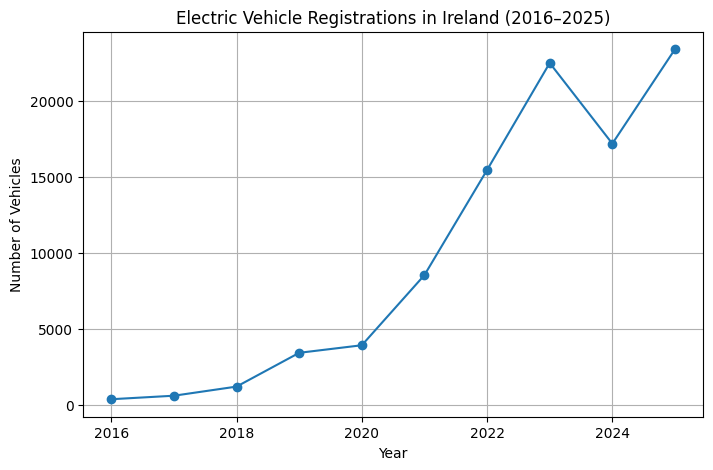

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    ev_yearly["Year"],
    ev_yearly["VALUE"],
    marker="o"
)

plt.title("Electric Vehicle Registrations in Ireland (2016–2025)")
plt.xlabel("Year")
plt.ylabel("Number of Vehicles")

plt.grid()

plt.show()

### Findings

The chart shows a strong increase in electric vehicle registrations over the period analysed. Growth accelerated significantly after 2020, reflecting increased adoption of electric vehicles in Ireland. Despite continued growth overall, annual registrations exhibited some volatility in the later years of the analysis period, highlighting the importance of examining growth rates and future adoption trends.

# **9. Cumulative Electric Vehicle Registrations (2016–2025)**

Progress Towards Ireland's 2030 EV Target.

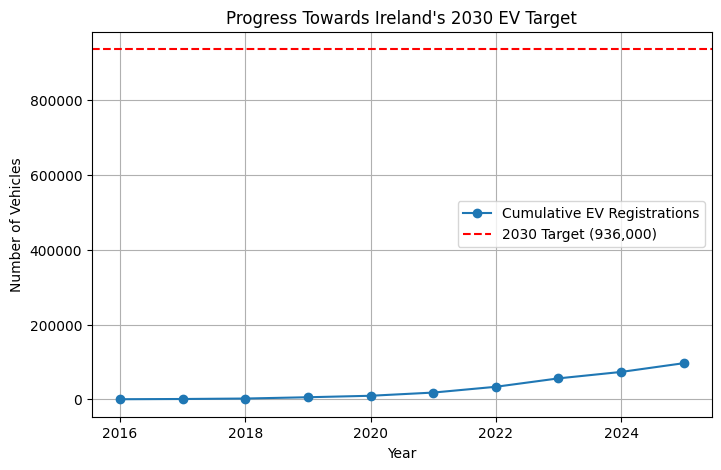

In [ ]:
target_2030 = 936000

plt.figure(figsize=(8,5))

plt.plot(
    ev_yearly["Year"],
    ev_yearly["Cumulative_EV"],
    marker="o",
    label="Cumulative EV Registrations"
)

plt.axhline(
    y=target_2030,
    linestyle="--",
    color="red",
    label="2030 Target (936,000)"
)

plt.title("Progress Towards Ireland's 2030 EV Target")
plt.xlabel("Year")
plt.ylabel("Number of Vehicles")

plt.legend()
plt.grid()

plt.show()

# Findings
The cumulative registration trend demonstrates sustained growth in electric vehicle adoption between 2016 and 2025. Although registrations increased substantially over the study period, the cumulative total remains significantly below Ireland's 2030 target of 936,000 electric vehicles. This highlights the scale of growth required over the remainder of the decade and provides a basis for further analysis of EV adoption trends and progress towards Ireland's long-term electrification objectives

# **10. Compare Battery Electric and Plug-in Hybrid Vehicle Registrations**
This section compares annual registrations of Battery Electric Vehicles (BEVs) and Plug-in Hybrid Electric Vehicles (PHEVs) between 2016 and 2025. The comparison provides additional insight into vehicle electrification trends and helps identify whether consumers are transitioning directly to fully electric vehicles or adopting plug-in hybrid technology as an intermediate step.

In [ ]:
# Create comparison dataset

df_compare = df[
    df["Type of Fuel"].isin([
        "Electric",
        "Petrol or Diesel plug-in hybrid electric"
    ])
].copy()

# Restrict period

df_compare = df_compare[
    (df_compare["Month"] >= "2016-01-01") &
    (df_compare["Month"] <= "2025-12-31")
]

# New Private Cars only

df_compare = df_compare[
    df_compare["Type of Vehicle Registration"] == "New Private Cars"
]

# Extract Year

df_compare["Year"] = df_compare["Month"].dt.year

In [ ]:
# Calculate annual registrations by fuel type

bev_phev_yearly = (
    df_compare
    .groupby(["Year", "Type of Fuel"])["VALUE"]
    .sum()
    .reset_index()
)

bev_phev_yearly

,Year,Type of Fuel,VALUE
0,2016,Electric,392.0
1,2016,Petrol or Diesel plug-in hybrid electric,283.0
2,2017,Electric,623.0
3,2017,Petrol or Diesel plug-in hybrid electric,259.0
4,2018,Electric,1222.0
5,2018,Petrol or Diesel plug-in hybrid electric,715.0
6,2019,Electric,3443.0
7,2019,Petrol or Diesel plug-in hybrid electric,1321.0
8,2020,Electric,3940.0
9,2020,Petrol or Diesel plug-in hybrid electric,2402.0


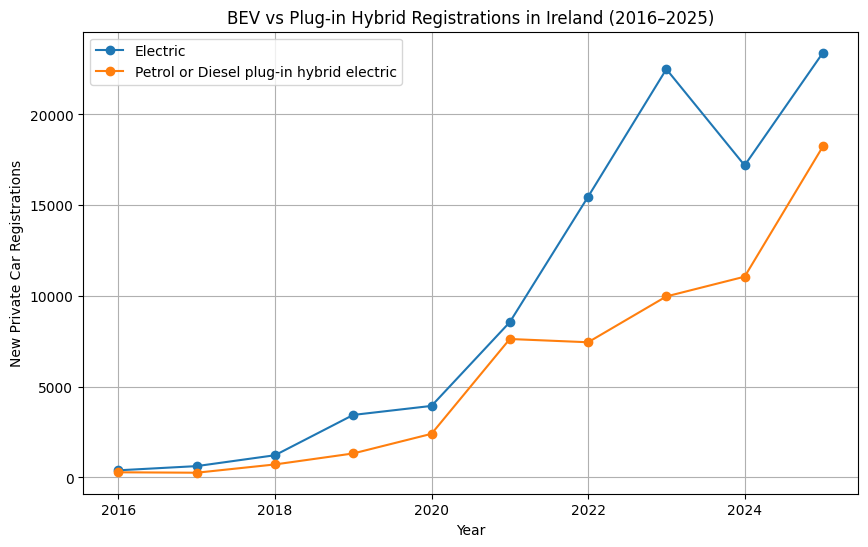

In [ ]:
plt.figure(figsize=(10,6))

for fuel in bev_phev_yearly["Type of Fuel"].unique():
    temp = bev_phev_yearly[
        bev_phev_yearly["Type of Fuel"] == fuel
    ]

    plt.plot(
        temp["Year"],
        temp["VALUE"],
        marker="o",
        label=fuel
    )

plt.title("BEV vs Plug-in Hybrid Registrations in Ireland (2016–2025)")
plt.xlabel("Year")
plt.ylabel("New Private Car Registrations")
plt.legend()
plt.grid()
plt.show()

### Findings

The results show substantial growth in both Battery Electric Vehicle (BEV) and Plug-in Hybrid Electric Vehicle (PHEV) registrations between 2016 and 2025. While registrations for both vehicle types increased significantly, BEVs consistently recorded higher registration volumes throughout the study period. Growth accelerated after 2020, reflecting increased consumer adoption of electrified vehicles in Ireland. Although a temporary decline in BEV registrations was observed in 2024, registrations recovered in 2025 and remained above PHEV levels. Overall, the findings suggest that fully electric vehicles have become the dominant form of vehicle electrification in Ireland, while PHEVs continue to play an important supporting role during the transition away from conventional petrol and diesel vehicles.

# **11. Analyse Annual EV Growth Rates**

In [ ]:
# Calculate year-on-year growth rate for BEV registrations

ev_yearly["YoY_Growth_%"] = ev_yearly["VALUE"].pct_change() * 100

ev_yearly

,Year,VALUE,Cumulative_EV,YoY_Growth_%
0,2016,392.0,392.0,NaN
1,2017,623.0,1015.0,58.928571
2,2018,1222.0,2237.0,96.147673
3,2019,3443.0,5680.0,181.751227
4,2020,3940.0,9620.0,14.435086
5,2021,8554.0,18174.0,117.106599
6,2022,15462.0,33636.0,80.757540
7,2023,22493.0,56129.0,45.472772
8,2024,17191.0,73320.0,-23.571778
9,2025,23398.0,96718.0,36.106102


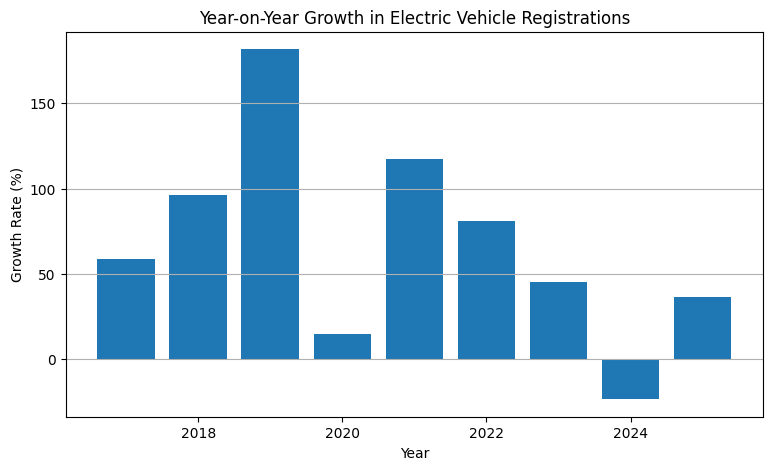

In [ ]:
plt.figure(figsize=(9,5))

plt.bar(
    ev_yearly["Year"],
    ev_yearly["YoY_Growth_%"]
)

plt.title("Year-on-Year Growth in Electric Vehicle Registrations")
plt.xlabel("Year")
plt.ylabel("Growth Rate (%)")
plt.grid(axis="y")
plt.show()

# Findings
Year-on-year growth rates highlight the rapid expansion of electric vehicle adoption in Ireland during the study period. Growth rates were particularly strong during the early stages of market development, exceeding 100% in several years. Although growth moderated in later years, annual registrations continued to increase overall. A temporary decline was observed in 2024 before growth resumed in 2025. These findings suggest that the Irish EV market is transitioning from an early high-growth phase towards a more mature stage of adoption, where future growth is likely to continue at a slower but more sustainable rate.